# 04 — Merchant Analysis (Block C)
## REVER Logistics Cost & Revenue Analysis — 2025

Answers Block C questions: margin by merchant, winner/loser profiling, churn detection, and adjustment ratios.

**Requires:** `01_preparacion.ipynb` to have been run first.

In [6]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
warnings.filterwarnings("ignore")

PROCESSED = Path("../processed")

PALETTE = {
    "primary": "#2C5F8A", "positive": "#2A9D8F", "negative": "#E63946",
    "neutral": "#ADB5BD", "accent": "#F4A261", "bg": "#FFFFFF", "grid": "#F0F0F0",
}
CARRIER_COLORS = {
    "Correos": "#F4A261", "Correos Express": "#E63946",
    "UPS": "#8B5E3C", "GLS": "#2A9D8F", "BRT": "#457B9D",
}

plt.rcParams.update({
    "figure.facecolor": PALETTE["bg"], "axes.facecolor": PALETTE["bg"],
    "axes.grid": True, "grid.color": PALETTE["grid"], "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": True, "axes.spines.bottom": True,
    "axes.edgecolor": "#CCCCCC", "font.family": "sans-serif", "font.size": 11,
    "axes.titlesize": 14, "axes.titleweight": "bold", "axes.labelsize": 11,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "legend.frameon": False, "legend.fontsize": 10,
    "figure.dpi": 110, "figure.figsize": (14, 5),
})
FIG_W, FIG_H = 14, 5

merged  = pd.read_parquet(PROCESSED / "merged.parquet")
matched = merged.dropna(subset=["rever_revenue_net"]).copy()
adj     = pd.read_parquet(PROCESSED / "adj.parquet")

print(f"matched: {len(matched):,} rows | merchants: {matched['stripe_cust_id'].nunique():,}")

matched: 244,149 rows | merchants: 408


---
## C1 — Margin by merchant

Top and bottom 20 merchants by total margin. Also shows which carrier each merchant primarily uses — helps diagnose whether low margin is a carrier assignment problem.

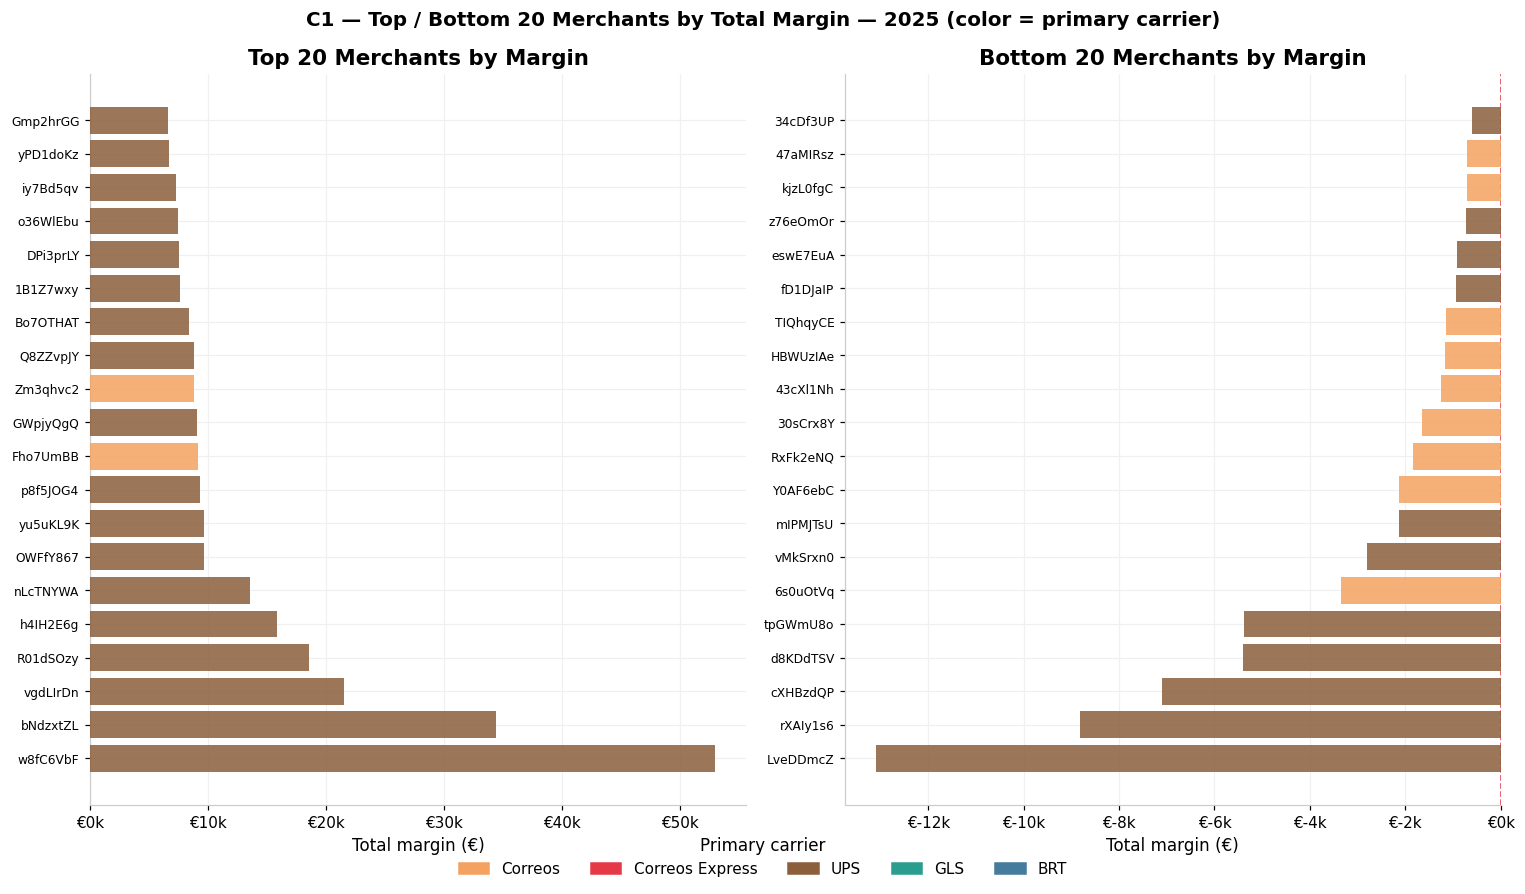

In [7]:
# ── C1: Top / bottom 20 merchants by total margin ────────────────────────────
merchant_margin = (
    matched.groupby("stripe_cust_id")
    .agg(
        shipments      = ("tracking_id",       "count"),
        total_revenue  = ("rever_revenue_net", "sum"),
        total_cost     = ("carrier_cost_net",  "sum"),
        total_margin   = ("margin_eur",        "sum"),
        avg_margin_eur = ("margin_eur",        "mean"),
        top_carrier    = ("carrier",           lambda x: x.value_counts().index[0]),
        avg_weight_kg  = ("billed_weight_kg",  "mean"),
    )
    .reset_index()
    .sort_values("total_margin", ascending=False)
)

top20    = merchant_margin.head(20)
bottom20 = merchant_margin.tail(20).sort_values("total_margin")

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H + 3))

# Top 20
colors_top = [CARRIER_COLORS.get(c, PALETTE["neutral"]) for c in top20["top_carrier"]]
axes[0].barh(range(len(top20)), top20["total_margin"], color=colors_top, alpha=0.85, zorder=3)
axes[0].set_yticks(range(len(top20)))
axes[0].set_yticklabels(top20["stripe_cust_id"].str[-8:], fontsize=8)
axes[0].set_title("Top 20 Merchants by Margin")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v/1_000:.0f}k"))
axes[0].set_xlabel("Total margin (€)")

# Bottom 20
colors_bot = [CARRIER_COLORS.get(c, PALETTE["neutral"]) for c in bottom20["top_carrier"]]
axes[1].barh(range(len(bottom20)), bottom20["total_margin"], color=colors_bot, alpha=0.85, zorder=3)
axes[1].axvline(0, color=PALETTE["negative"], linewidth=1, linestyle="--")
axes[1].set_yticks(range(len(bottom20)))
axes[1].set_yticklabels(bottom20["stripe_cust_id"].str[-8:], fontsize=8)
axes[1].set_title("Bottom 20 Merchants by Margin")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v/1_000:.0f}k"))
axes[1].set_xlabel("Total margin (€)")

# Legend: carrier colors
from matplotlib.patches import Patch
legend_patches = [Patch(color=c, label=n) for n, c in CARRIER_COLORS.items()]
fig.legend(handles=legend_patches, title="Primary carrier", loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("C1 — Top / Bottom 20 Merchants by Total Margin — 2025 (color = primary carrier)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## C2 & C3 — Winner / Loser quadrant

Scatter: X = shipment volume, Y = avg margin per shipment.
Top-right = strategic merchants (high volume + high margin).
Bottom-left = candidates for repricing or deprioritisation.

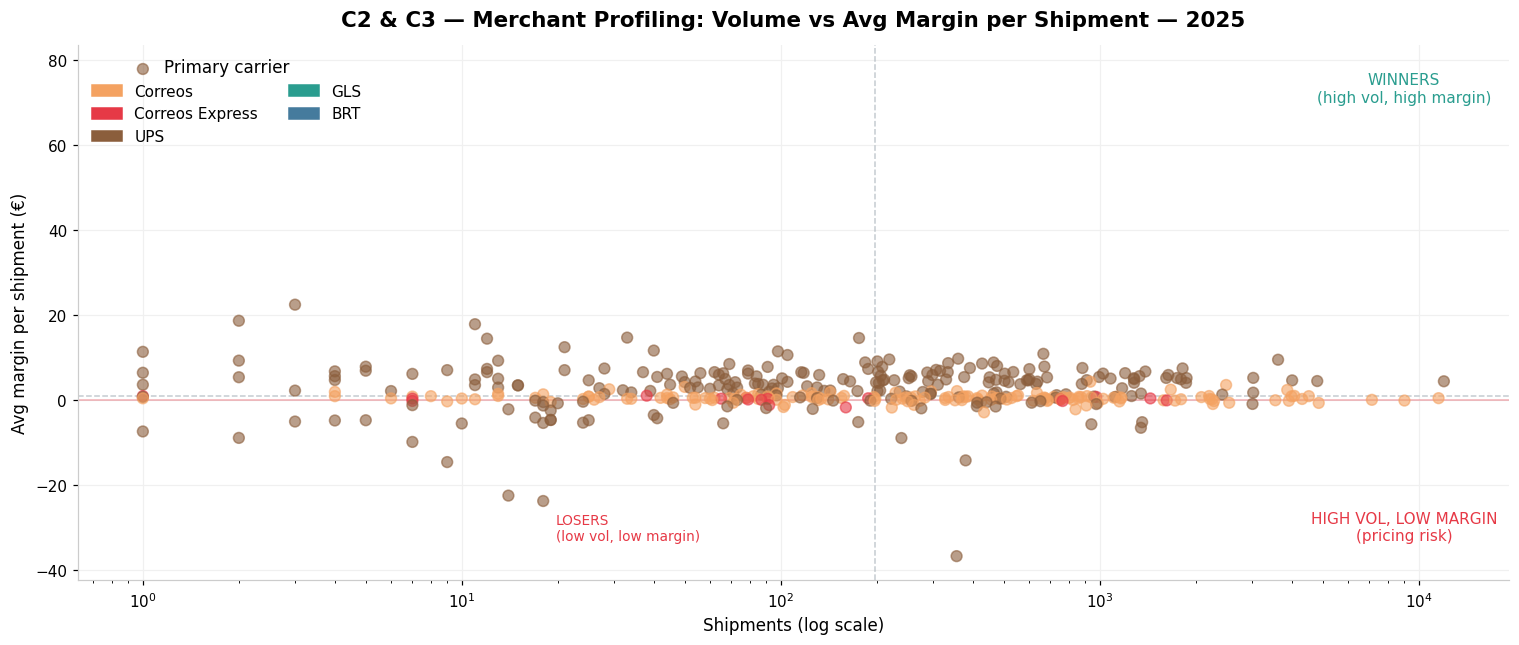

In [8]:
# ── C2 & C3: Winner / Loser quadrant (volume × avg margin) ───────────────────
vol_median = merchant_margin["shipments"].median()
mg_median  = merchant_margin["avg_margin_eur"].median()

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H + 1))

colors_scatter = [CARRIER_COLORS.get(c, PALETTE["neutral"]) for c in merchant_margin["top_carrier"]]
ax.scatter(merchant_margin["shipments"], merchant_margin["avg_margin_eur"],
           c=colors_scatter, alpha=0.6, s=50, zorder=3)

ax.axvline(vol_median, color=PALETTE["neutral"], linewidth=1, linestyle="--", alpha=0.7)
ax.axhline(mg_median,  color=PALETTE["neutral"], linewidth=1, linestyle="--", alpha=0.7)

ax.text(merchant_margin["shipments"].max() * 0.75, merchant_margin["avg_margin_eur"].max() * 0.9,
        "WINNERS\n(high vol, high margin)", color=PALETTE["positive"], fontsize=10, ha="center")
ax.text(merchant_margin["shipments"].max() * 0.75, merchant_margin["avg_margin_eur"].min() * 0.9,
        "HIGH VOL, LOW MARGIN\n(pricing risk)", color=PALETTE["negative"], fontsize=10, ha="center")
ax.text(vol_median * 0.1, merchant_margin["avg_margin_eur"].min() * 0.9,
        "LOSERS\n(low vol, low margin)", color=PALETTE["negative"], fontsize=9, ha="left")

from matplotlib.patches import Patch
legend_patches = [Patch(color=c, label=n) for n, c in CARRIER_COLORS.items()]
ax.legend(handles=legend_patches, title="Primary carrier", loc="upper left", ncol=2)

ax.set_xscale("log")
ax.set_xlabel("Shipments (log scale)")
ax.set_ylabel("Avg margin per shipment (€)")
ax.axhline(0, color=PALETTE["negative"], linewidth=1, linestyle="-", alpha=0.4)
ax.set_title("C2 & C3 — Merchant Profiling: Volume vs Avg Margin per Shipment — 2025", pad=12)
plt.tight_layout()
plt.show()

---
## C4 — Churn detection

Which merchants were active early in 2025 but stopped sending shipments?
A merchant with no activity in the last 2+ months may have churned.

Active merchants (last 2 months): 318
Potentially churned              : 90
Never exceeded 1 active month   : 30


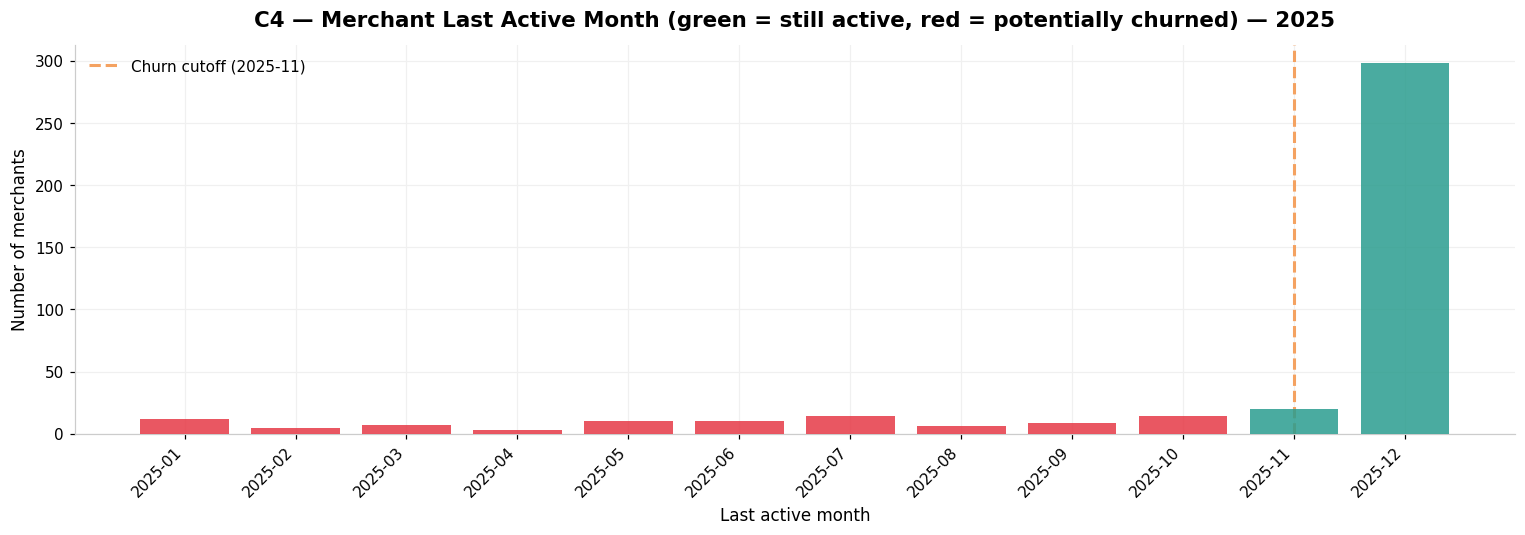

In [9]:
# ── C4: Churn detection ───────────────────────────────────────────────────────
last_month = matched["month"].max()
months_sorted = sorted(matched["month"].unique())

# For each merchant: first active month, last active month, total months active
merchant_activity = (
    matched.groupby("stripe_cust_id")["month"]
    .agg(first_month="min", last_month="max", active_months="nunique")
    .reset_index()
)

# Churned = had activity before last 2 months, but nothing in last 2 months
cutoff = months_sorted[-2] if len(months_sorted) >= 2 else months_sorted[-1]
churned = merchant_activity[
    (merchant_activity["first_month"] <= cutoff) &
    (merchant_activity["last_month"]  <  cutoff)
].copy()
active = merchant_activity[merchant_activity["last_month"] >= cutoff]

print(f"Active merchants (last 2 months): {len(active):,}")
print(f"Potentially churned              : {len(churned):,}")
print(f"Never exceeded 1 active month   : {(merchant_activity['active_months'] == 1).sum():,}")

# Bar chart: merchant count by last active month
last_month_dist = merchant_activity.groupby("last_month").size().reset_index(name="merchants")
colors_churn = [PALETTE["positive"] if m >= cutoff else PALETTE["negative"]
                for m in last_month_dist["last_month"]]

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
ax.bar(last_month_dist["last_month"], last_month_dist["merchants"],
       color=colors_churn, alpha=0.85, zorder=3)
ax.axvline(cutoff, color=PALETTE["accent"], linewidth=2, linestyle="--", label=f"Churn cutoff ({cutoff})")
ax.set_xticklabels(last_month_dist["last_month"], rotation=45, ha="right")
ax.set_ylabel("Number of merchants")
ax.set_xlabel("Last active month")
ax.legend()
ax.set_title("C4 — Merchant Last Active Month (green = still active, red = potentially churned) — 2025", pad=12)
plt.tight_layout()
plt.show()

---
## C5 — Adjustment ratio per merchant

For each merchant: total adjustments billed (from `adj` table) as a % of total revenue.
A high ratio means the merchant consistently generates extra charges (weight adjustments, remote zone surcharges, etc.).

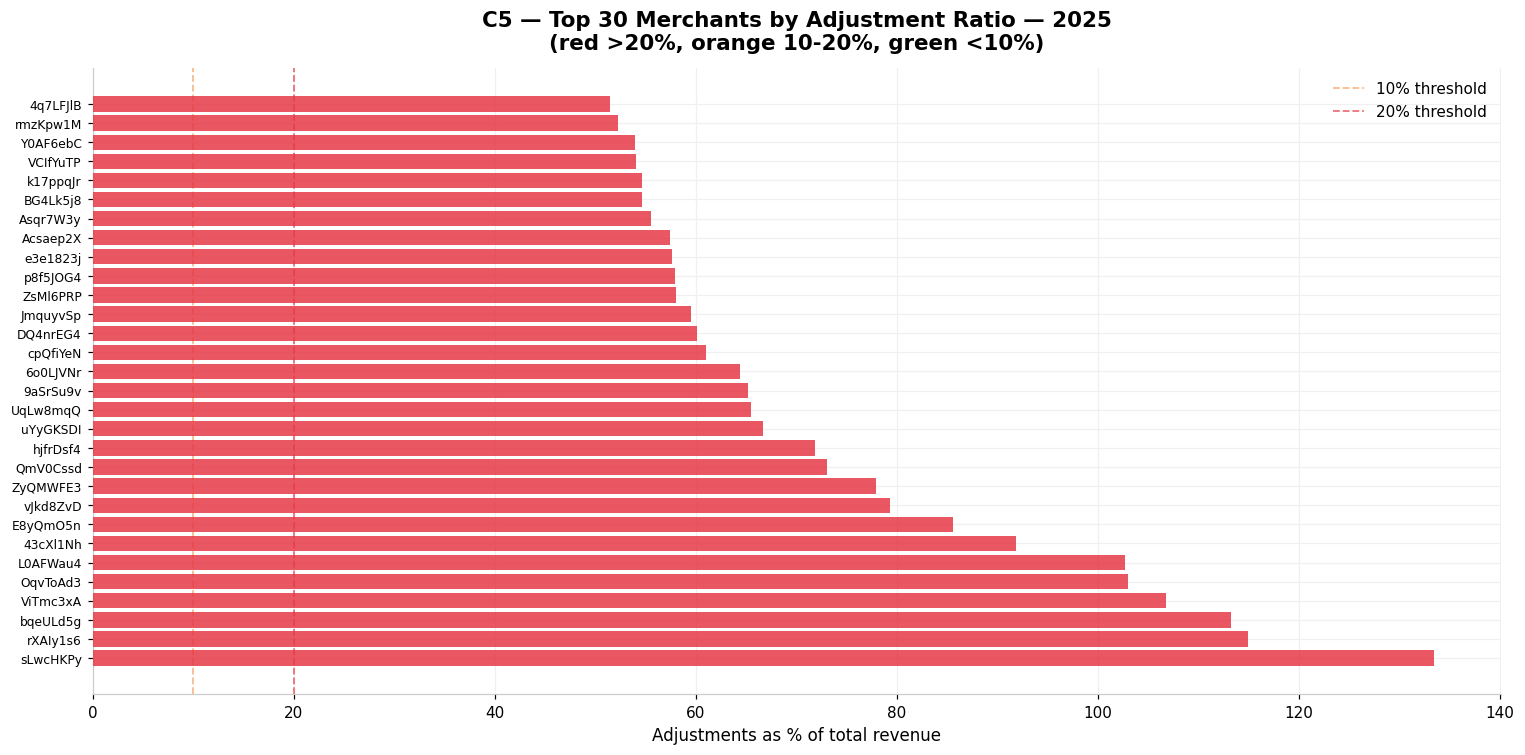

In [10]:
# ── C5: Adjustment ratio per merchant (top 30 by ratio) ──────────────────────
merchant_revenue = (
    matched.groupby("stripe_cust_id")["rever_revenue_net"].sum().reset_index()
    .rename(columns={"rever_revenue_net": "total_revenue"})
)
merchant_adj = (
    adj.groupby("stripe_cust_id")["subtotal"].sum().reset_index()
    .rename(columns={"subtotal": "total_adj"})
)
adj_ratio = merchant_revenue.merge(merchant_adj, on="stripe_cust_id", how="left")
adj_ratio["total_adj"]   = adj_ratio["total_adj"].fillna(0)
adj_ratio["adj_ratio"]   = adj_ratio["total_adj"] / adj_ratio["total_revenue"].replace(0, float("nan")) * 100
adj_ratio = adj_ratio[adj_ratio["total_revenue"] > 100].sort_values("adj_ratio", ascending=False)

top30 = adj_ratio.head(30)

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H + 2))
bar_colors = [PALETTE["negative"] if r > 20 else PALETTE["accent"] if r > 10 else PALETTE["positive"]
              for r in top30["adj_ratio"]]
ax.barh(range(len(top30)), top30["adj_ratio"], color=bar_colors, alpha=0.85, zorder=3)
ax.set_yticks(range(len(top30)))
ax.set_yticklabels(top30["stripe_cust_id"].str[-8:], fontsize=8)
ax.axvline(10, color=PALETTE["accent"],   linewidth=1.2, linestyle="--", alpha=0.7, label="10% threshold")
ax.axvline(20, color=PALETTE["negative"], linewidth=1.2, linestyle="--", alpha=0.7, label="20% threshold")
ax.set_xlabel("Adjustments as % of total revenue")
ax.legend()
ax.set_title("C5 — Top 30 Merchants by Adjustment Ratio — 2025\n(red >20%, orange 10-20%, green <10%)", pad=12)
plt.tight_layout()
plt.show()

---
## C6 — Churned merchant profitability

90 merchants stopped operating in the last 2 months of 2025.
Were they profitable accounts (lost to competition) or loss-making accounts (good riddance)?
This determines whether churn is a revenue risk or a margin improvement.

Churned merchants (no activity since 2025-11): 90
  Profitable churned (lost good accounts)    : 59
  Loss-making churned (good riddance)        : 31
  Total revenue from churned                 : €101,520
  Total margin from churned                  : €16,926

Avg margin/shipment — active   : €1.85
Avg margin/shipment — churned  : €1.28


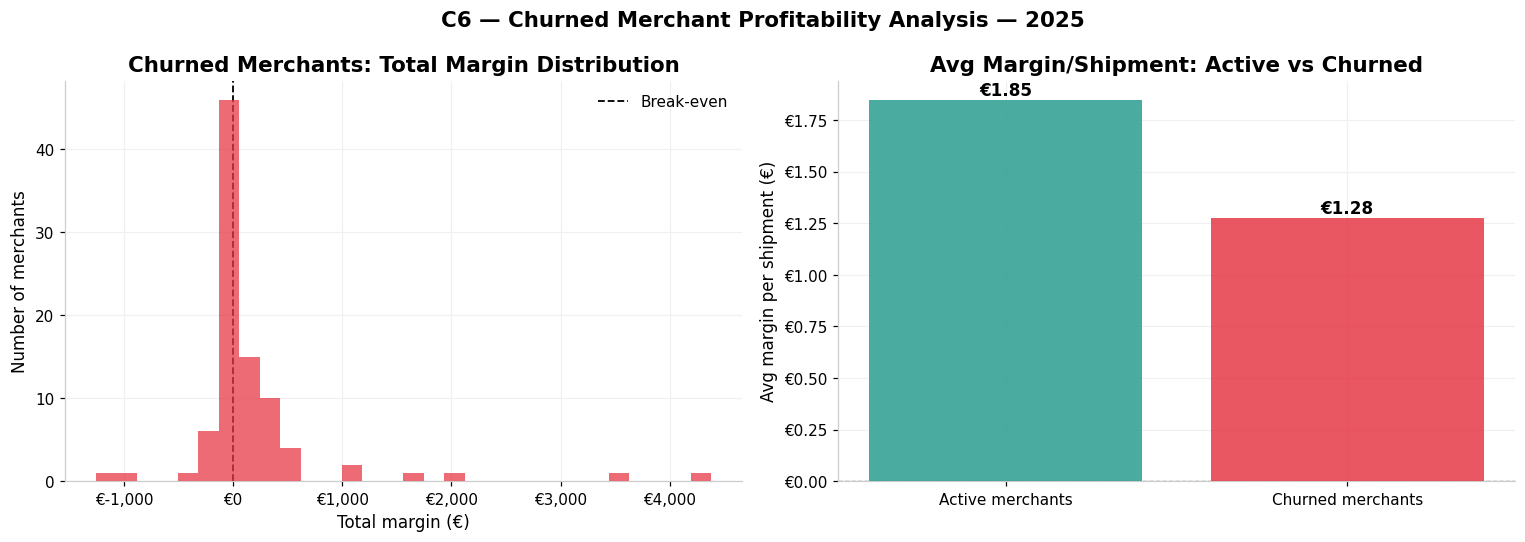

In [11]:
# ── C6: Churned merchant profitability ────────────────────────────────────────
all_months = sorted(matched["month"].unique())
cutoff     = all_months[-2]  # last 2 months = still active threshold

recent_active = set(matched[matched["month"] >= cutoff]["stripe_cust_id"].unique())
ever_active   = set(matched["stripe_cust_id"].unique())
churned_ids   = ever_active - recent_active

churned_data = matched[matched["stripe_cust_id"].isin(churned_ids)]
active_data  = matched[~matched["stripe_cust_id"].isin(churned_ids)]

churned_summary = (
    churned_data.groupby("stripe_cust_id")
    .agg(shipments=("tracking_id", "count"),
         total_revenue=("rever_revenue_net", "sum"),
         total_margin=("margin_eur", "sum"),
         avg_margin=("margin_eur", "mean"))
    .reset_index()
    .sort_values("total_margin", ascending=False)
)

profitable_churned = (churned_summary["total_margin"] > 0).sum()
loss_churned       = (churned_summary["total_margin"] <= 0).sum()

print(f"Churned merchants (no activity since {cutoff}): {len(churned_ids):,}")
print(f"  Profitable churned (lost good accounts)    : {profitable_churned}")
print(f"  Loss-making churned (good riddance)        : {loss_churned}")
print(f"  Total revenue from churned                 : €{churned_data['rever_revenue_net'].sum():,.0f}")
print(f"  Total margin from churned                  : €{churned_summary['total_margin'].sum():,.0f}")
print()
print(f"Avg margin/shipment — active   : €{active_data['margin_eur'].mean():.2f}")
print(f"Avg margin/shipment — churned  : €{churned_data['margin_eur'].mean():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H))

# Left: distribution of churned merchant total margin
axes[0].hist(churned_summary["total_margin"], bins=30,
             color=PALETTE["negative"], alpha=0.75, zorder=3)
axes[0].axvline(0, color="black", linewidth=1.2, linestyle="--", label="Break-even")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v:,.0f}"))
axes[0].set_title("Churned Merchants: Total Margin Distribution")
axes[0].set_xlabel("Total margin (€)")
axes[0].set_ylabel("Number of merchants")
axes[0].legend()

# Right: avg margin comparison active vs churned
comp = pd.DataFrame({
    "Group": ["Active merchants", "Churned merchants"],
    "Avg margin/shipment (€)": [active_data["margin_eur"].mean(), churned_data["margin_eur"].mean()]
})
bar_colors = [PALETTE["positive"], PALETTE["negative"]]
axes[1].bar(comp["Group"], comp["Avg margin/shipment (€)"], color=bar_colors, alpha=0.85, zorder=3)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v:.2f}"))
axes[1].set_title("Avg Margin/Shipment: Active vs Churned")
axes[1].set_ylabel("Avg margin per shipment (€)")
for i, val in enumerate(comp["Avg margin/shipment (€)"]):
    axes[1].text(i, val + 0.02 * (1 if val >= 0 else -1),
                 f"€{val:.2f}", ha="center", fontsize=11, fontweight="bold")

fig.suptitle("C6 — Churned Merchant Profitability Analysis — 2025", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()